In [1]:
%%capture --no-stderr
%pip install --quiet -U langgraph langchain-core langchain-perplexity


In [2]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("PPLX_API_KEY")


PPLX_API_KEY:  ········


In [11]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

builder = StateGraph(State)
builder.add_node("assistant", assistant)
builder.set_entry_point("assistant")
builder.add_edge("assistant", END)

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)


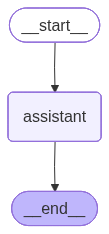

In [12]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))


In [13]:
initial_input = {
    "messages": [HumanMessage(content="Convert 35 degrees Celsius to Fahrenheit.")]
}

thread = {"configurable": {"thread_id": "example-thread-1"}}

for event in graph.stream(initial_input, config=thread, stream_mode="values"):
    print("New state:")
    for msg in event["messages"]:
        print(f"{msg.type}: {msg.content}")
    print("-" * 40)


New state:
human: Convert 35 degrees Celsius to Fahrenheit.
----------------------------------------
New state:
human: Convert 35 degrees Celsius to Fahrenheit.
ai: 35 degrees Celsius is equal to **95 degrees Fahrenheit**[1][2][3][4][6][8][9].

This conversion uses the standard formula:

\[
°F = (°C \times \frac{9}{5}) + 32
\]

For 35°C:

\[
°F = (35 \times \frac{9}{5}) + 32 = 63 + 32 = 95
\]

All major temperature conversion charts and calculators confirm this result[1][2][3][4][6][8][9].
----------------------------------------


In [9]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
graph = builder.compile(checkpointer=memory)


In [14]:
from langchain_core.messages import HumanMessage

thread = {"configurable": {"thread_id": "thread-1"}}

initial_input = {
    "messages": [
        HumanMessage(content="Convert 35 degrees Celsius to Fahrenheit.")
    ]
}

for event in graph.stream(initial_input, config=thread, stream_mode="values"):
    event["messages"][-1].pretty_print()
    print("-" * 40)


================================ Human Message =================================

Convert 35 degrees Celsius to Fahrenheit.
----------------------------------------
================================== Ai Message ==================================

**35 degrees Celsius is equal to 95 degrees Fahrenheit**[1][2][3][4][6][9].

The conversion uses the formula:

\[
°F = (°C \times \frac{9}{5}) + 32
\]

Applying this to 35°C:

\[
°F = (35 \times \frac{9}{5}) + 32 = 63 + 32 = 95
\]

This result is confirmed across multiple temperature conversion charts and calculators[1][2][3][4][6][9].
----------------------------------------


In [15]:
initial_input_2 = {
    "messages": [
        HumanMessage(
            content="Add 120 and 350, then multiply the result by 2. Answer with just the final number."
        )
    ]
}

thread2 = {"configurable": {"thread_id": "example-thread-2"}}

for event in graph.stream(initial_input_2, config=thread2, stream_mode="values"):
    last = event["messages"][-1]
    print("Latest message:")
    print(last.type, ":", last.content)


Latest message:
human : Add 120 and 350, then multiply the result by 2. Answer with just the final number.
Latest message:
ai : The final number is **940**.


In [16]:
single_run = graph.invoke(
    {
        "messages": [
            HumanMessage(
                content="Explain in one sentence what a computation graph is."
            )
        ]
    },
    config={"configurable": {"thread_id": "example-thread-3"}},
)

single_run["messages"][-1].pretty_print()


================================== Ai Message ==================================

A **computation graph** is a directed graph in which nodes represent mathematical operations or variables, and edges represent the flow of data between operations, providing a structured way to visualize and evaluate mathematical expressions or computational processes[1][3][7][9].


In [17]:
single_run_2 = graph.invoke(
    {
        "messages": [
            HumanMessage(
                content="Give me a fun fact about space in one short sentence."
            )
        ]
    },
    config={"configurable": {"thread_id": "example-thread-4"}},
)

single_run_2["messages"][-1].pretty_print()


================================== Ai Message ==================================

**Space is completely silent because there is no air for sound to travel through**[5].


In [18]:
initial_input_3 = {
    "messages": [
        HumanMessage(
            content="List three popular programming languages in a single sentence."
        )
    ]
}

thread3 = {"configurable": {"thread_id": "example-thread-5"}}

for event in graph.stream(initial_input_3, config=thread3, stream_mode="values"):
    print("Streaming step:")
    event["messages"][-1].pretty_print()
    print("-" * 40)


Streaming step:
================================ Human Message =================================

List three popular programming languages in a single sentence.
----------------------------------------
Streaming step:
================================== Ai Message ==================================

Three popular programming languages are **Python**, **Java**, and **JavaScript**[1][3][4]. 

Python consistently ranks as the most popular language due to its versatility and ease of use, Java remains widely used for enterprise and Android development, and JavaScript is essential for web development[1][3][4]. Other sources confirm these three are among the top choices for both new and experienced programmers in 2025[3][4][11].
----------------------------------------
